# Классификация сердечных заболеваний

## Постановка задачи


Импортируем некоторые полезные библиотеки:

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score

# Для красивых графиков
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
sns.set_style("whitegrid")

Сердечно-сосудистые заболевания (ССЗ) остаются основной причиной смертности во всем мире. По оценкам Всемирной организации здравоохранения, ежегодно от них умирает около 17,9 миллиона человек, что составляет примерно 31% всех случаев смерти. Значительная часть этих смертей связана с сердечными приступами и инсультами, причем треть из них происходит преждевременно — у людей младше 70 лет.

Сердечная недостаточность является одним из наиболее распространенных последствий ССЗ. Для оценки риска заболевания используются различные клинические показатели и факторы риска, такие как гипертония, диабет, уровень холестерина и другие медицинские параметры.

Современные методы анализа данных позволяют использовать такие признаки для прогнозирования наличия или вероятности развития заболевания.

> Таким образом, перед нами возникает типичная задача машинного обучения — **задача классификации**, где на основе набора признаков необходимо определить, **относится ли пациент к классу людей с заболеванием сердца или нет**.



На первом этапе нам необходимо загрузить данные. Мы будем использовать датасет с платформы Kaggle. Для этого выполним следующую ячейку:

In [ ]:
import kagglehub
andrewmvd_heart_failure_clinical_data_path = kagglehub.dataset_download('andrewmvd/heart-failure-clinical-data')
fedesoriano_heart_failure_prediction_path = kagglehub.dataset_download('fedesoriano/heart-failure-prediction')

Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.
Using Colab cache for faster access to the 'heart-failure-prediction' dataset.


После загрузки датасета считаем его в датафрейм и посмотрим на первые строки таблицы, чтобы понять структуру данных:

In [ ]:
# Пытаемся найти файл датасета как в Kaggle Notebook, так и после kagglehub.dataset_download(...)
possible_paths = [
    "/kaggle/input/heart-failure-prediction/heart.csv",
    os.path.join(fedesoriano_heart_failure_prediction_path, "heart.csv"),
]

csv_path = None
for p in possible_paths:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    # запасной вариант: ищем heart.csv внутри скачанной папки
    for root, dirs, files in os.walk(fedesoriano_heart_failure_prediction_path):
        if "heart.csv" in files:
            csv_path = os.path.join(root, "heart.csv")
            break

if csv_path is None:
    raise FileNotFoundError("Файл heart.csv не найден")

df = pd.read_csv(csv_path)
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# Exploratory Data Analysis

После загрузки данных нельзя сразу переходить к обучению модели.
Сначала нужно задать себе вопрос:

> Какие у нас данные? Насколько они адекватны?

Если мы не понимаем структуру данных, распределения и возможные проблемы, модель может:

*   Учиться на ошибках в данных
*   Учитывать случайные шумы
*   Давать нестабильные результаты


In [ ]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


В pandas текстовые данные часто имеют тип `object`. Однако тип `object является универсальным и может содержать не только строки, но и данные других типов.

Для корректной обработки категориальных признаков явно приведем такие столбцы к строковому типу `string`:

In [ ]:
string_col = df.select_dtypes(include="object").columns
df[string_col]=df[string_col].astype("string")
df.dtypes

,0
Age,int64
Sex,string[python]
ChestPainType,string[python]
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,string[python]
MaxHR,int64
ExerciseAngina,string[python]
Oldpeak,float64



**Вопрос:**

*   Что является целевой переменной?

### Ответ


**Что является целевой переменной?**

Целевой переменной является столбец `HeartDisease`.

Почему?

- Именно его мы хотим предсказать.
- Он принимает значения:
  - `0` — заболевание отсутствует  
  - `1` — заболевание присутствует  

Следовательно, перед нами стоит задача **бинарной классификации**, где по набору медицинских признаков пациента необходимо определить его принадлежность к одному из двух классов.

Формально:

- **X** — матрица признаков (Age, Cholesterol, RestingBP и др.)
- **y** — целевая переменная `HeartDisease`

Требуется построить отображение:

$$
X \rightarrow y
$$

# Что важно понять про данные?
1.   Есть ли пропущенные значения?
2.   Есть ли необычно большие или маленькие значения? Есть ли перекосы?
3.   Отличаются ли пациенты с заболеванием от пациентов без него?

Используя LLM для генерации кода, ответьте на данные вопросы про качество и структуру данных.

**Шаг 1**
- Посчитайте количество пропусков в каждом столбце с помощью `df.isnull().sum()`.
- Отсортируйте результат по убыванию, чтобы сверху были столбцы с наибольшим числом пропусков.

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


**Шаг 2**
- Определите список числовых признаков.
- Убедитесь, что вы не включили целевую переменную HeartDisease в список числовых признаков (если она попала туда — удалите её).
- Постройте гистограммы для всех числовых признаков одной командой.

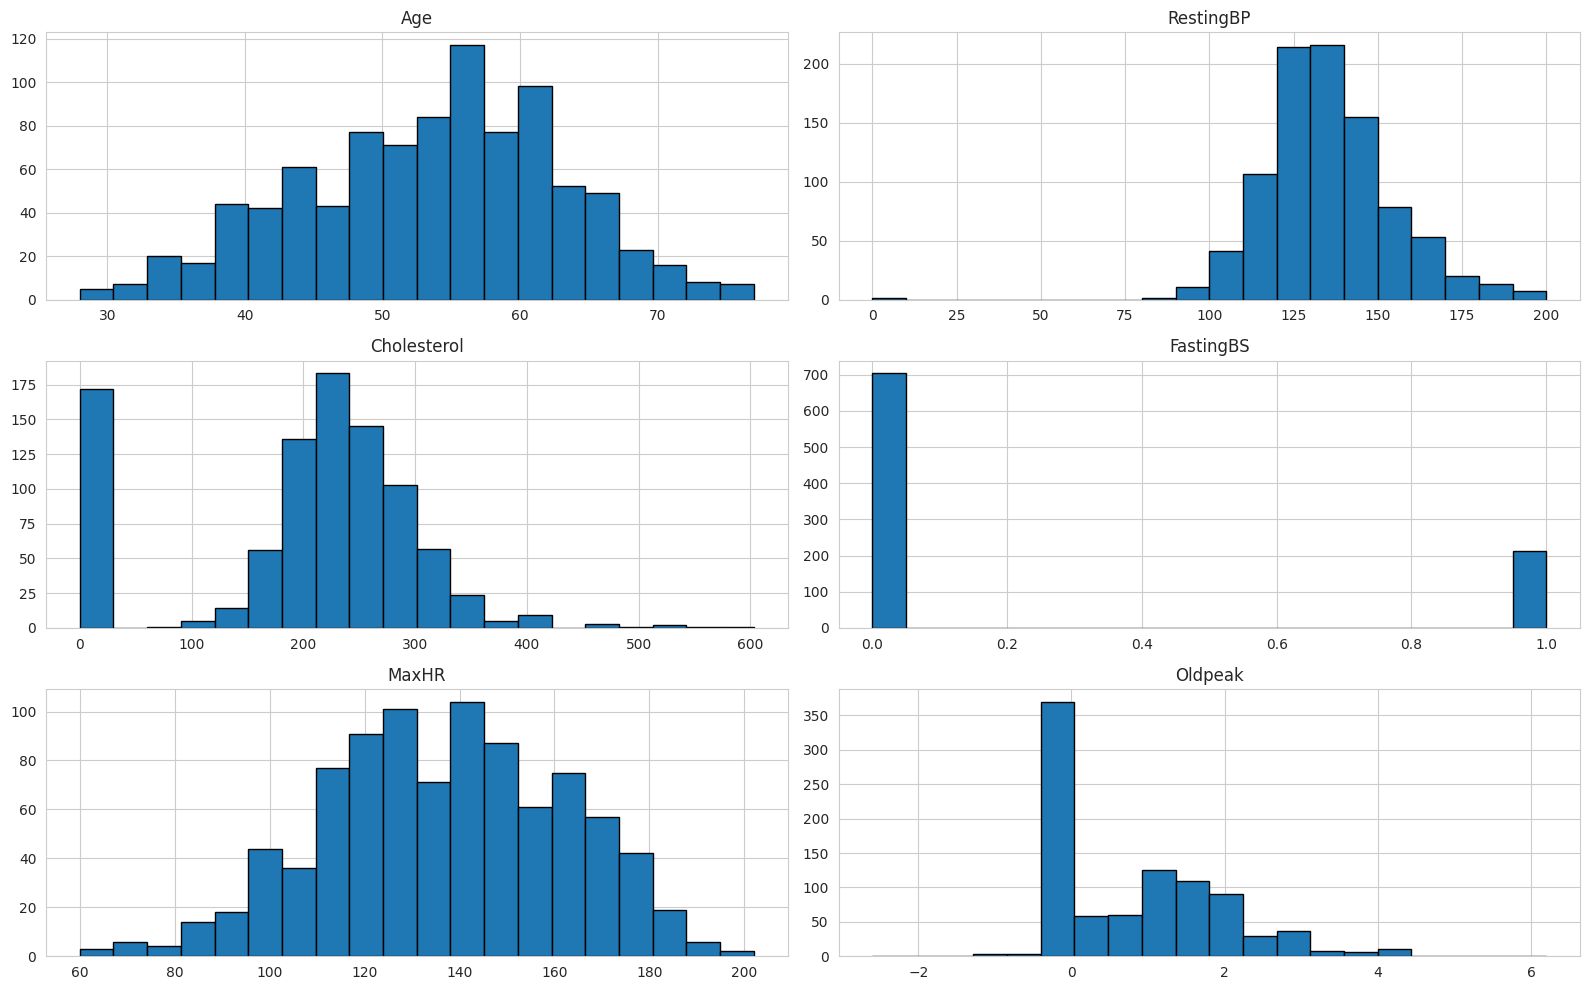

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if "HeartDisease" in numeric_cols:
    numeric_cols.remove("HeartDisease")

df[numeric_cols].hist(figsize=(16, 10), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

numeric_cols

**Шаг 3**

Для каждого из числовых признаков постройте `boxplot`, где:
- по оси `X`: `HeartDisease`
- по оси `Y`: числовой признак

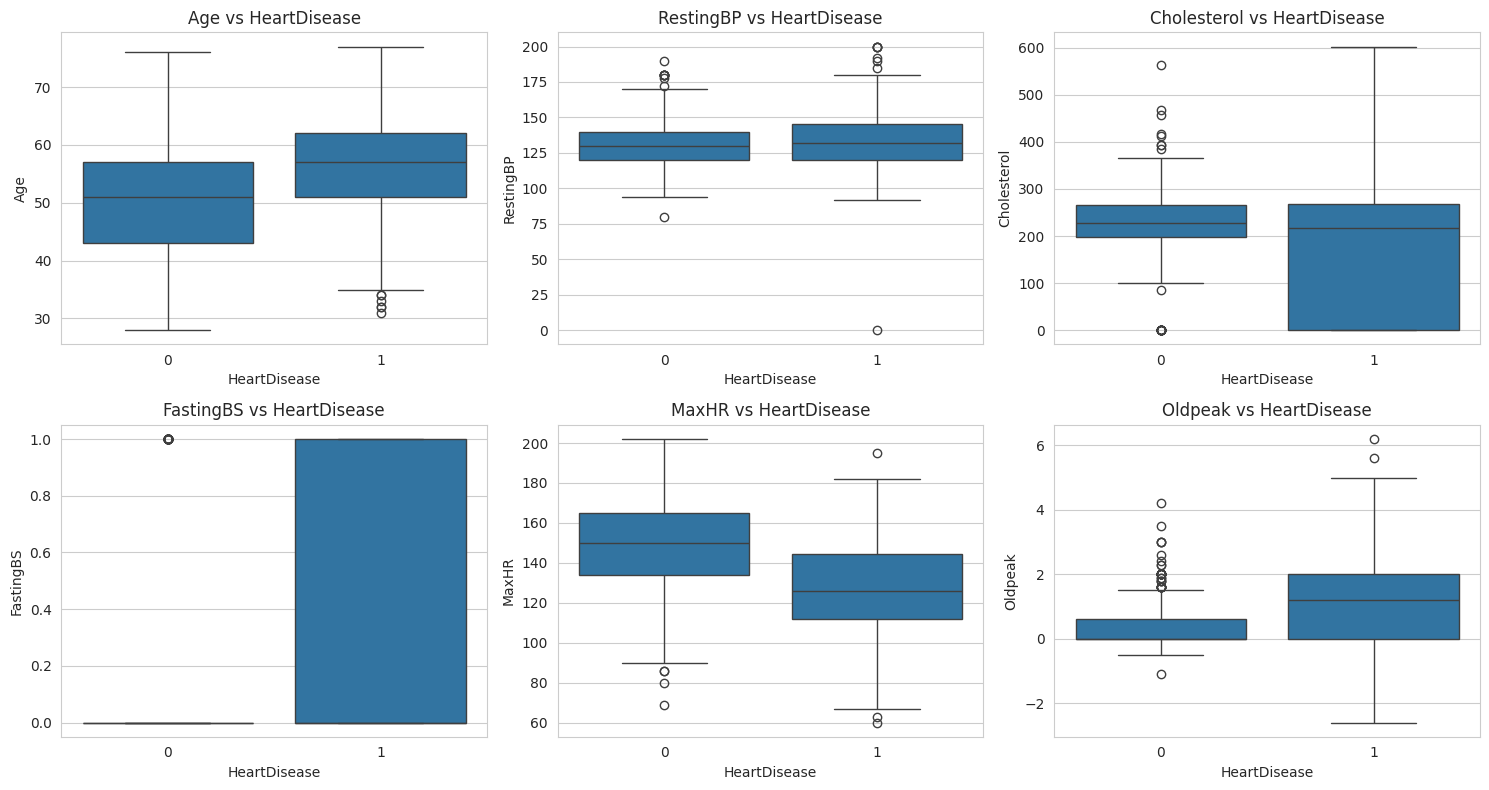

In [ ]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="HeartDisease", y=col, ax=ax)
    ax.set_title(f"{col} vs HeartDisease")

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

**Вывод:** в данных отсутствуют пропущенные значения, однако у некоторых числовых признаков наблюдается асимметрия распределений и присутствуют выбросы (особенно у `Cholesterol` и `Oldpeak`). Пациенты с заболеванием в среднем старше, имеют более низкий `MaxHR` и более высокий `Oldpeak`, что указывает на различия между группами и потенциальную информативность этих признаков.

# Data preprocessing

**Вопросы:**

* Находятся ли признаки в одном масштабе или в разных (например, `Age` и `Cholesterol`)?
* Может ли это повлиять на обучение модели?
* Нужно ли кодировать признаки?

### Ответ

Во время анализа мы увидели, что числовые признаки имеют разный масштаб. Например, возраст принимает значения примерно от 30 до 70, а уровень холестерина может доходить до 600. Если оставить всё как есть, признаки с большими числовыми значениями могут начать «доминировать» над признаками с меньшими значениями. Некоторые алгоритмы машинного обучения чувствительны к масштабу данных, поэтому важно привести числовые признаки к сопоставимому виду.

Для этого используется масштабирование (`scaling`) — преобразование, при котором признаки приводятся к единому масштабу, сохраняя при этом их относительные различия.

Кроме того, в данных присутствуют категориальные признаки — например, тип боли в груди или наклон сегмента ST. Эти признаки представлены текстовыми значениями. Однако математическая модель не умеет работать с текстом напрямую. Поэтому такие признаки необходимо преобразовать в числовой формат.

Важно сделать это корректно: мы не можем просто заменить категории числами 1, 2, 3, потому что тогда модель может интерпретировать их как упорядоченные значения. Вместо этого используется `One-Hot Encoding` — метод, при котором каждая категория превращается в отдельный бинарный столбец (0 или 1). Это позволяет сохранить информацию о категории без создания искусственного порядка.

# Нормализация и кодирование данных

Используя LLM для генерации кода, выполните шаги ниже и ответьте на вопросы.

**Шаг 1**
* Создайте матрицу признаков `X` и вектор целевой переменной `y`
* Разделите данные на тренировочную и тестовую части в сооношении `80:20` при помощи `train_test_split` из библиотеки `sklearn`. Для воспроизводимости зафиксируйте `random_state=42`, `stratify=y` (чтобы пропорции классов в train/test были похожими)

In [ ]:
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер X_train:", X_train.shape)
print("Размер X_test :", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test :", y_test.shape)

Размер X_train: (734, 11)
Размер X_test : (184, 11)
Размер y_train: (734,)
Размер y_test : (184,)


**Шаг 2**
* Найдите список категориальных признаков
* Создайте объект `ColumnTransformer` , который делает преобразование `StandardScaler()` для числовых признаков и `OneHotEncoder()` для категориальных признаков
* Обучите препроцессор только на обучающей выборке
* Примените те же преобразования к тестовой

In [ ]:
categorical_cols = X.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Категориальные признаки:", categorical_cols)
print("Числовые признаки:", numeric_cols)
print("Размер после преобразования (train):", X_train_processed.shape)
print("Размер после преобразования (test) :", X_test_processed.shape)

Категориальные признаки: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Числовые признаки: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Размер после преобразования (train): (734, 20)
Размер после преобразования (test) : (184, 20)


## Кросс-валидация

Теперь данные находятся в формате, пригодном для обучения модели. Но возникает важный **вопрос**:

> Достаточно ли одного разбиения на `train` и `test`, чтобы сделать надёжный вывод о работе модели?



### Ответ


Когда мы делим данные только один раз, результат может зависеть от конкретного случайного разбиения. В обучающую выборку могли попасть более «простые» примеры, а в тестовую — более «сложные», или наоборот. В таком случае итоговый результат может оказаться случайно завышенным или заниженным. Мы получаем только одну оценку и не понимаем, насколько она устойчива.

Чтобы сделать выводы более надёжными, можно использовать другой подход. Вместо одного разбиения данные делятся на несколько частей. Модель обучается несколько раз, каждый раз на разных поднаборах данных, а проверяется на оставшейся части. Затем результаты усредняются. Такой способ позволяет получить более стабильную и объективную оценку работы модели.

Этот подход называется кросс-валидацией.

<img src="https://i.stack.imgur.com/8uEci.png" width=50%>

В нашей задаче это особенно важно, потому что мы работаем с бинарной классификацией пациентов (наличие или отсутствие заболевания). Важно, чтобы при каждом разбиении в обучающих и проверочных частях сохранялось разумное соотношение классов. Именно поэтому далее мы будем использовать стратифицированную кросс-валидацию, которая сохраняет пропорции классов в каждом разбиении и делает оценку модели более корректной.


# Обучение моделей классификации

Теперь, когда данные подготовлены, мы можем переходить к обучению моделей.

**Важно понимать:**
не существует универсального алгоритма, который всегда работает лучше остальных. Разные модели делают разные предположения о структуре данных и по-разному ищут границу между классами.

Поэтому мы обучим несколько алгоритмов и сравним их поведение.

Чтобы лучше понять, как разные алгоритмы работают с нашими данными, мы рассмотрим модели разных типов. У каждого подхода своя логика построения границы между классами и свои предположения о структуре данных.

1.   Логистическая регрессия
2.   Наивный Байес
3.   SVM (метод опорных векторов)
4.   k ближайших соседей (KNN)



# Наивный Байес
Наивный Байес — вероятностный классификатор, основанный на формуле Байеса. Он предполагает, что признаки **условно независимы** при фиксированном классе (это и есть “наивное” предположение).

Пусть $y\in\{0,1\}$ — класс, а $x=(x_1,\dots,x_d)$ — вектор признаков. Тогда по формуле Байеса:
$$
P(y\mid x)=\frac{P(y)\,P(x\mid y)}{P(x)}.
$$

- $P(y\mid x)$ — **апостериорная вероятность**: насколько вероятен класс $y$, *если мы уже увидели признаки* $x$. Это то, что нам нужно для классификации.
- $P(y)$ — **априорная вероятность** класса: насколько часто класс $y$ встречается “в среднем”, до просмотра признаков.
- $P(x\mid y)$ — **правдоподобие**: насколько вероятно получить такие признаки $x$, если известно, что объект принадлежит классу $y$.
- $P(x)$ — **нормировочный множитель**: вероятность встретить признаки $x$ вообще, независимо от класса.

Для выбора класса важно сравнить вероятности $P(y\mid x)$ для разных $y$. Заметим, что $P(x)$ **одно и то же число** для всех классов (ведь признаки $x$ фиксированы). Поэтому при сравнении классов знаменатель можно не учитывать:
$$
\hat y=\arg\max_y P(y)\,P(x\mid y).
$$
Это означает: мы выбираем тот класс, для которого произведение “частоты класса” $P(y)$ и “насколько хорошо класс объясняет признаки” $P(x\mid y)$ — максимальное.

### Наивное предположение: как упрощается $P(x\mid y)$

Вычислять $P(x\mid y)$ напрямую сложно, потому что $x$ — многомерный вектор, и нужна модель для совместного распределения всех признаков сразу. Наивный Байес делает упрощение:

> если класс $y$ известен, то признаки $x_1,\dots,x_d$ независимы.

Формально это записывается так:
$$
P(x\mid y)=\prod_{j=1}^d P(x_j\mid y).
$$

Смысл: вероятность “увидеть одновременно все признаки” при классе $y$ заменяется произведением вероятностей “увидеть каждый признак по отдельности” при том же классе. Это сильное допущение, но оно резко упрощает обучение: вместо одной сложной модели мы оцениваем много простых распределений $P(x_j\mid y)$.

Тогда правило классификации принимает вид:
$$
\hat y=\arg\max_y \left( P(y)\prod_{j=1}^d P(x_j\mid y)\right).
$$

Интуитивно: мы берём базовую “популярность” класса $P(y)$ и умножаем её на вклад каждого признака — насколько этот признак типичен для данного класса.

### Почему переходят к логарифмам

Произведение большого числа вероятностей может стать очень маленьким (возникают численные проблемы). Кроме того, с суммами удобнее работать, чем с произведениями. Поэтому обычно переходят к логарифмам.

Поскольку логарифм монотонно возрастает, максимум не меняется:
$$
\hat y=\arg\max_y \left( \log P(y)+\sum_{j=1}^d \log P(x_j\mid y)\right).
$$

Здесь видно важное:

- $\log P(y)$ — “базовый сдвиг” в пользу класса, зависящий от того, насколько класс часто встречается.
- $\sum_{j=1}^d \log P(x_j\mid y)$ — сумма вкладов признаков: каждый признак добавляет (или вычитает) аргументы в пользу класса в зависимости от того, насколько он характерен для этого класса.

Именно поэтому наивный Байес часто хорошо работает на задачах вроде классификации текста: каждый “признак” (слово/счётчик) вносит независимый вклад в общую оценку класса.

#Support Vector Machine

SVM строит разделяющую гиперплоскость и стремится **максимизировать зазор (margin)** между классами. Решение определяется небольшой частью объектов — **опорными векторами**.

Пусть $y_i\in\{-1,+1\}$ и гиперплоскость задаётся:
$$
w^\top x + b = 0.
$$

### Линейно разделимый случай (жёсткий зазор)
SVM выбирает $w,b$, чтобы все точки были классифицированы правильно с запасом:
$$
y_i(w^\top x_i+b)\ge 1,\quad i=1,\dots,n,
$$
и при этом минимизирует норму $w$ (что эквивалентно максимизации зазора):
$$
\min_{w,b}\ \frac{1}{2}\|w\|^2.
$$

### Неразделимый случай (мягкий зазор)
Разрешаем нарушения с помощью штрафа (hinge loss). Стандартная постановка:
$$
\min_{w,b}\ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \max\bigl(0,\ 1-y_i(w^\top x_i+b)\bigr).
$$
Здесь $C>0$ — параметр баланса:
- большой $C$ сильнее наказывает ошибки $\Rightarrow$ модель старается лучше подогнаться под обучение;
- маленький $C$ допускает больше нарушений $\Rightarrow$ больше регуляризация, граница “проще”.

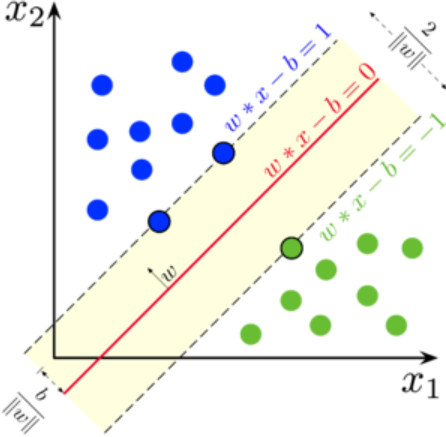

С помощью LLM сгенерируйте код, который:

**Шаг 1**
- Создаёт **StratifiedKFold** на 5 фолдов (с перемешиванием и фиксированным `random_state=42`), чтобы **пропорции классов** сохранялись в каждом фолде.
- Задаёт словарь **метрик** (`accuracy`, `precision`, `recall`, `f1`, `roc_auc`) для оценки качества.
  - Для `precision/recall/f1` использует `make_scorer(..., zero_division=0)`, чтобы метрики корректно считались даже если модель ни разу не предсказала класс 1.
  - `roc_auc` — метрика ранжирования, работает с `predict_proba` или `decision_function`.
- Создаёт словарь `models` и добавляет в него:
  - **Логистическую регрессию** (`max_iter=2000` для надёжной сходимости),
  - **Наивный Байес (GaussianNB)** через `Pipeline` (добавляем перевод в dense после препроцессинга),
  - **SVM** с RBF-ядром (`probability=True`),
  - **KNN** с `n_neighbors=5`

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score),
    "roc_auc": "roc_auc",
}

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "GaussianNB": GaussianNB(),
    "SVC": SVC(probability=True, random_state=42),
    "KNeighborsClassifier": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
}

rows = []

print("Количество моделей:", len(models))
print("Модели:", list(models.keys()))

Количество моделей: 8
Модели: ['LogisticRegression', 'GaussianNB', 'SVC', 'KNeighborsClassifier', 'DecisionTreeClassifier', 'RandomForestClassifier', 'GradientBoostingClassifier', 'AdaBoostClassifier']


С помощью LLM сгенерируйте код, который для каждой модели из словаря `models` посчитаем метрики на стратифицированной кросс-валидации и соберет итоговую таблицу со средними значениями метрик

**Шаг 2**
- Создаёт пустой список `rows`, куда будет по одной строке добавлять результаты для каждой модели.
- Проходит циклом по всем моделям из `models`:
  - Если модель уже является `Pipeline` (как GaussianNB), использует её как есть.
  - Иначе оборачивает модель в `Pipeline`, добавляя одинаковый `preprocessor` перед классификатором.
- Для каждой модели запускает `cross_validate`:
  - передаёт `X, y`, объект кросс-валидации `cv` и словарь метрик `scoring`,
  - `n_jobs=-1` — использовать все доступные ядра процессора для ускорения,
  - `return_train_score=False` — не считает метрики на обучающей части фолдов.
- Из результатов `cross_validate` берёт метрики тестовой части (`test_*`) и считает:
  - среднее значение (mean) для каждой метрики,
  - стандартное отклонение (std) для ROC-AUC (как оценку стабильности).
- Собирает `pd.DataFrame`, сортирует по `ROC-AUC (mean)` и выводит таблицу.

In [ ]:
for name, model in models.items():
    if isinstance(model, Pipeline):
        pipe = model
    else:
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

    cv_result = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    rows.append({
        "model": name,
        "accuracy": cv_result["test_accuracy"].mean(),
        "precision": cv_result["test_precision"].mean(),
        "recall": cv_result["test_recall"].mean(),
        "f1": cv_result["test_f1"].mean(),
        "roc_auc": cv_result["test_roc_auc"].mean(),
    })

cv_results = pd.DataFrame(rows).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)
cv_results

,model,accuracy,precision,recall,f1,roc_auc
0,RandomForestClassifier,0.858345,0.857640,0.896597,0.875710,0.928250
1,LogisticRegression,0.850172,0.858036,0.876935,0.866879,0.924752
2,SVC,0.854263,0.851048,0.899036,0.873246,0.924352
3,GradientBoostingClassifier,0.854282,0.870722,0.867058,0.867911,0.923220
4,AdaBoostClassifier,0.851524,0.862073,0.874466,0.867669,0.922569
5,GaussianNB,0.848803,0.872608,0.852304,0.861971,0.913042
6,KNeighborsClassifier,0.848775,0.848269,0.889190,0.867676,0.902430
7,DecisionTreeClassifier,0.790187,0.821634,0.800512,0.809149,0.789114


**Шаг 3**
- Проходит по всем моделям из словаря `models`:
  - Если модель уже `Pipeline`, использует её как есть.
  - Иначе оборачивает модель в `Pipeline`, добавляя одинаковую предобработку `preprocessor`.
- Обучает `pipe.fit(X_train, y_train)`.
- Получает **скор/оценку** для класса 1 на `X_test`:
  - если у модели есть `predict_proba`, берёт вероятности класса 1: `predict_proba(...)[:, 1]`;
  - иначе использует `decision_function`.
- Строит ROC-кривую:
  - считает пары точек `(FPR, TPR)` с помощью `roc_curve(y_test, y_proba)`,
  - считает ROC-AUC с помощью `roc_auc_score(y_test, y_proba)`.
- Рисует ROC-кривую каждой модели и подписывает её именем и AUC.
- Добавляет диагональ (это случайный классификатор).
- Оформляет график: подписи осей, заголовок, легенду, сетку.

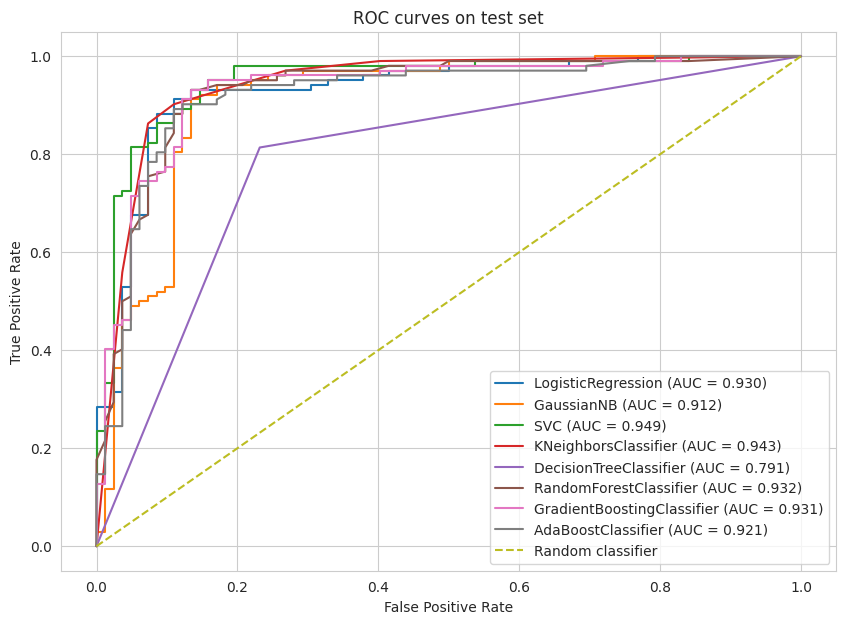

,model,accuracy,precision,recall,f1,roc_auc
0,SVC,0.896739,0.887850,0.931373,0.909091,0.949426
1,KNeighborsClassifier,0.896739,0.910891,0.901961,0.906404,0.943089
2,RandomForestClassifier,0.891304,0.894231,0.911765,0.902913,0.931851
3,GradientBoostingClassifier,0.891304,0.901961,0.901961,0.901961,0.930655
4,LogisticRegression,0.885870,0.871560,0.931373,0.900474,0.929938
5,AdaBoostClassifier,0.885870,0.900990,0.892157,0.896552,0.921210
6,GaussianNB,0.885870,0.893204,0.901961,0.897561,0.911765
7,DecisionTreeClassifier,0.793478,0.813725,0.813725,0.813725,0.791009


In [ ]:
test_rows = []

plt.figure(figsize=(10, 7))

for name, model in models.items():
    if isinstance(model, Pipeline):
        pipe = model
    else:
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

    pipe.fit(X_train, y_train)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    y_pred = pipe.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.3f})")

    test_rows.append({
        "model": name,
        "accuracy": np.mean(y_pred == y_test),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": auc_value,
    })

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on test set")
plt.legend()
plt.grid(True)
plt.show()

test_results = pd.DataFrame(test_rows).sort_values(by="roc_auc", ascending=False).reset_index(drop=True)
test_results